# Part 4: Data Visualization & Machine Learning

## Theme: Student Performance Analysis & Prediction

Analyse a student performance dataset, produce meaningful visualizations, and build a machine learning model to predict whether a student will pass or fail — end to end.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("students.csv")

# 1. Print first 5 rows
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [7]:
# 2. Print the shape of the dataset:

print("Shape (rows × columns) :", df.shape)

# Data type of each column:

print(" Data Types of each column: \n",df.dtypes)

Shape (rows × columns) : (15, 9)
 Data Types of each column: 
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [8]:
# 3. Summary statistics (mean, min, max, std) for all numeric columns
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               

In [9]:
# Value of Pass/fail count:

print("\nPass / Fail Count:")
print(df['passed'].value_counts())



Pass / Fail Count:
passed
1    9
0    6
Name: count, dtype: int64


In [17]:
# 4. Average score per subject (math, science, english, history, pe) separately for passing and failing students.

subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print(f" Average score of Passing Student:\n{pass_avg}\n")
print(f" Average score of Failing Student:\n{fail_avg}")

 Average score of Passing Student:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

 Average score of Failing Student:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [21]:
# 5. Student with the highest overall average across all 5 subjects

df['avg_score'] = df[subject_cols].mean(axis=1) # create avgScore column to store all average score data

top_student = df.loc[df['avg_score'].idxmax()] #idmax to find the index/label of the maximum value of that column

print("Top Student:\n", top_student[['name', 'avg_score']])

Top Student:
 name         Diana
avg_score     94.0
Name: 3, dtype: object


## Task 2 — Data Visualization with Matplotlib

In [20]:
import matplotlib.pyplot as plt

In [22]:
print(subject_cols)

['math', 'science', 'english', 'history', 'pe']


In [27]:
print(df.columns) # to check avg_score column is available

Index(['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct',
       'study_hours_per_day', 'passed', 'avgSscore', 'avg_score'],
      dtype='object')


### Bar Chart:
Average score per subject across all students (one bar per subject, x-axis = subject name, y-axis = average score).



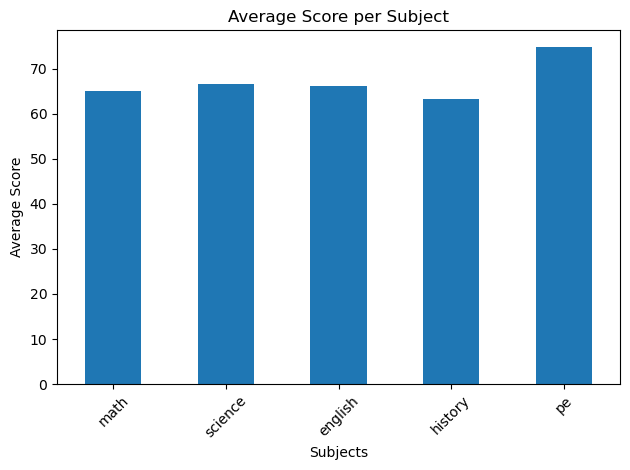

In [28]:
avg_scores = df[subject_cols].mean() 

plt.figure()
avg_scores.plot(kind='bar') 
plt.title("Average Score per Subject") #Give title
plt.xlabel("Subjects") # Give x label value: Subjects
plt.ylabel("Average Score") # Give y label value: Average Score
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot1_bar.png") # Save the image
plt.show()

### Histogram:
Distribution of math scores. Use 5 bins. Add a vertical dashed line at the mean math score and label it.

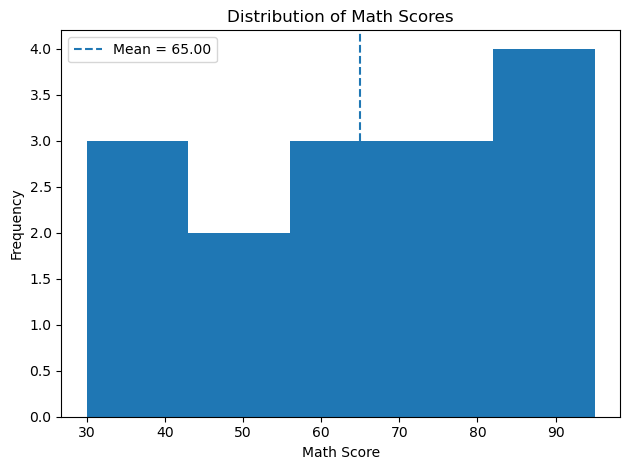

In [29]:
plt.figure()

# Plot histogram with 5 bins
plt.hist(df['math'], bins=5)

# Calculate mean of math score
mean_math = df['math'].mean()

# Add vertical dashed line at mean value
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()

plt.savefig("plot2_hist.png")
plt.show()

### Scatter Plot:

Study_hours_per_day (x-axis) vs avg_score (y-axis). Colour each point differently based on passed: one colour for Pass, another for Fail. Include a legend.

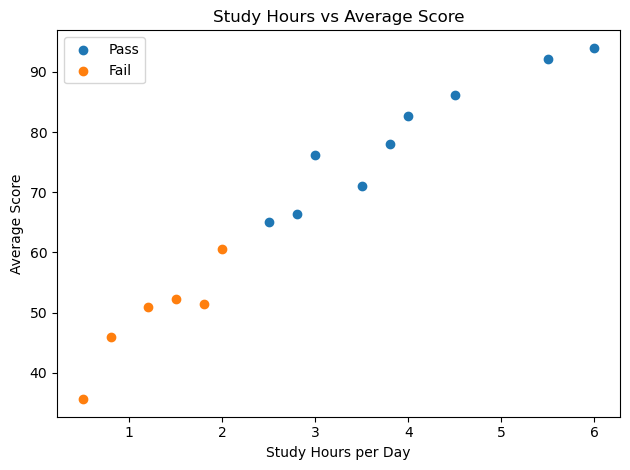

In [30]:
plt.figure()

# Separate data into Pass and Fail groups
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

# Plot passing students
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")

# Plot failing students
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")

plt.legend() # Show legend (Pass vs Fail)
plt.tight_layout()

plt.savefig("plot3_scatter.png")
plt.show()

### Box Plot:

Show the distribution of attendance_pct for passing students vs failing students side by side.


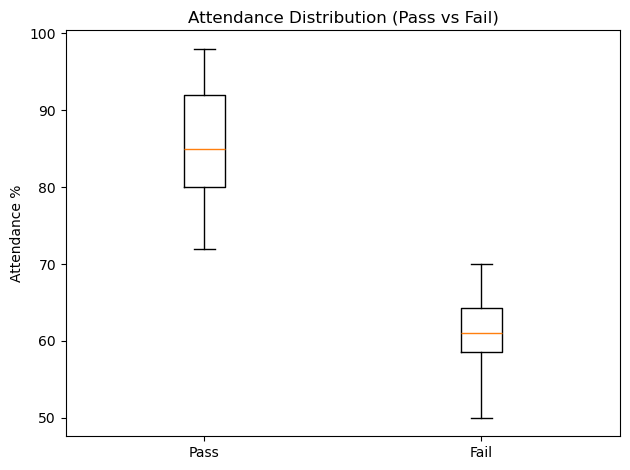

In [31]:
# Convert attendance values into lists for boxplot
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()

# Boxplot comparing Pass vs Fail attendance
plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance %")

plt.tight_layout()
plt.savefig("plot4_box.png")
plt.show()

### Line Plot:

Plot the math score and science score for every student. X-axis = student name, Y-axis = score. Use different line styles or markers for each subject.

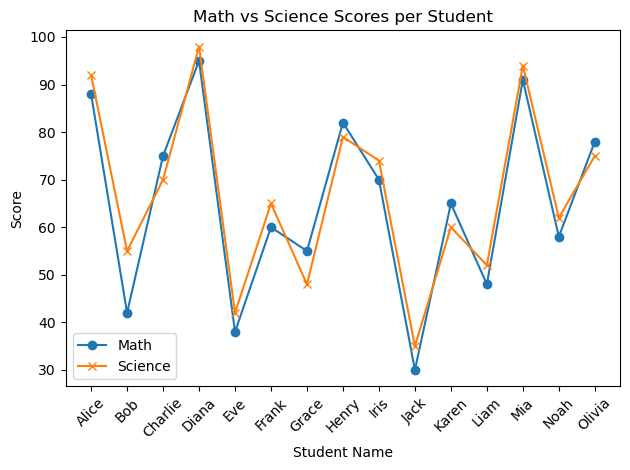

In [32]:
plt.figure()

# Plot Math scores with marker 'o'
plt.plot(df['name'], df['math'], marker='o', label="Math")

# Plot Science scores with marker 'x'
plt.plot(df['name'], df['science'], marker='x', label="Science")

plt.title("Math vs Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)                 # Rotate names for readability
plt.legend()                            # Show legend

plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

## Task 3 — Data Visualization with Seaborn

In [34]:
%pip install seaborn

In [35]:
import seaborn as sns

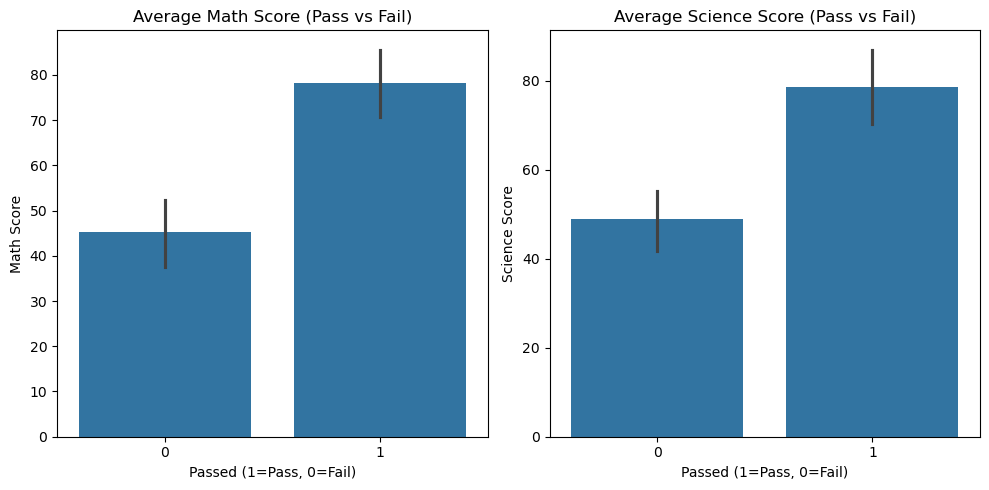

In [46]:
# Seaborn bar plot showing the average math score and average science score, split by passed (Pass vs Fail).

plt.figure(figsize=(10, 5))

# Average Math score plot:
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math') # Calculates average and plots it
plt.title("Average Math Score (Pass vs Fail)")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Math Score")

# Average Sceince score plot:
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Average Science Score (Pass vs Fail)")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

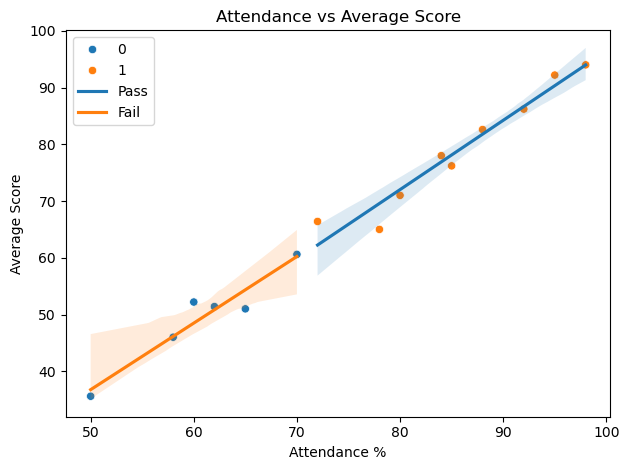

In [47]:
# Seaborn scatter plot of attendance_pct (x-axis) vs avg_score (y-axis). Add a regression line for each group (Pass and Fail) on the same axes.

plt.figure()

# Scatter plot colored by 'passed'
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for Pass students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# Regression line for Fail students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")

plt.legend()
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [38]:
# Seaborn makes statistical plots like barplots and regression plots much easier. Seabororn automatically computes the average.
# Matplotlib required more work as we had to seperatley compare average and requires more line of code.


## Task 4 — Machine Learning with scikit-learn

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


Build a classifier to predict whether a student will pass or fail.

Features (X): math, science, english, history, pe, attendance_pct, study_hours_per_day
Target (y): passed

### Step 1 — Prepare Data:

In [41]:
# Define features and target
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]   # exclude 'name'
y = df['passed']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# Scale features (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


### Step 2 — Train a Model:

In [42]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_preds = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_preds)
print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


### Step 3 — Evaluate the Model:

In [43]:
test_preds = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_preds) #get the accuracy score
print("Test Accuracy:", test_acc)

print("\nTest Predictions:")
names = df.loc[X_test.index, 'name'] # Selects the 'name' column for the specific rows whose labels are present in the X_test.index

for name, actual, pred in zip(names, y_test, test_preds):
    result = "✅" if actual == pred else "❌"
    print(f"{name}: Actual={actual}, Predicted={pred} {result}")


Test Accuracy: 1.0

Test Predictions:
Jack: Actual=0, Predicted=0 ✅
Liam: Actual=0, Predicted=0 ✅
Alice: Actual=1, Predicted=1 ✅


### Step 4 — Feature Importance:


Feature Importance (sorted):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


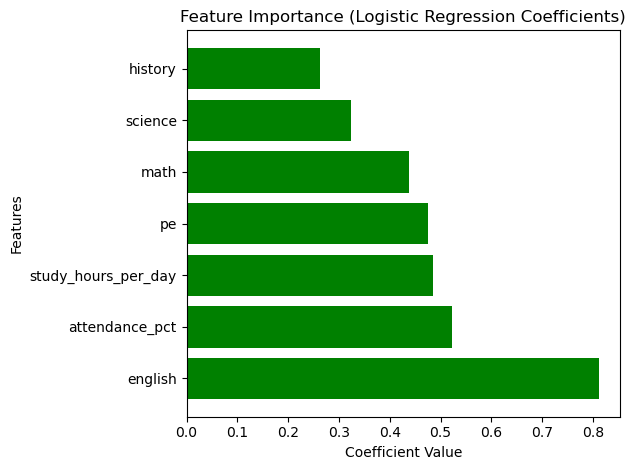

In [44]:
coefficients = model.coef_[0]

# Pair features with coefficients
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value (most important first)
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):")
for feat, coef in feature_importance:
    print(f"{feat}: {coef:.4f}")

# Plot coefficients
features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

# Color based on sign
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()
plt.barh(features, values, color=colors)

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### Step 5 — Predict for a New Student (Bonus — 2 marks):

In [45]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scale using same scaler
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("Prediction:", result)
print(f"Probability (Fail, Pass): {probability}")

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]
